In [2]:
import torch
import torchvision
print(f"Torch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Torch version: 2.4.1
Torchvision version: 0.19.1


In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# os.environ["DEEPFACE_HOME"] = "/projects/kzh"
os.environ["XFORMERS_DISABLED"] = "1" 

import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import numpy as np

from gazelle.model import get_gazelle_model
from retinaface import RetinaFace

/opt/miniconda3/envs/siq2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'gdown'

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# load Gaze-LLE model
torch.hub.set_dir(r'/Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main')
model, transform = torch.hub.load('fkryan/gazelle', 'gazelle_dinov2_vitl14_inout')

# model, transform = get_gazelle_model("gazelle_dinov2_vitb14_inout")
# model.load_gazelle_state_dict(torch.load("/projects/kzh/gazelle/checkpoint/gazelle_dinov2_vitl14_inout.pt", weights_only=True))

model.eval()
model.to(device)

Using device: cpu


Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/fkryan_gazelle_main
Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/facebookresearch_dinov2_main


GazeLLE(
  (backbone): DinoV2Backbone(
    (model): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-23): 24 x NestedTensorBlock(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=1024, out_features=4096, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=4096, out_features=1024, bias=True)
            (drop): Dropout(p=0.0, inpla

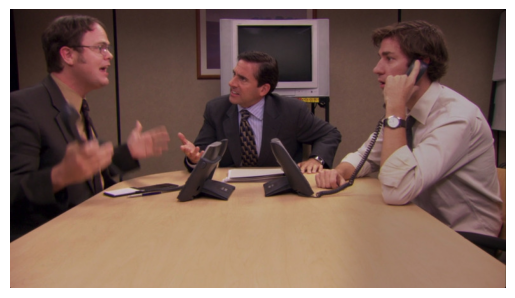

In [4]:
# load an input image

image_url = "https://www.looper.com/img/gallery/the-office-funniest-moments-ranked/jim-and-dwights-customer-service-training-1627594561.jpg"
# image_url = "https://ew.com/thmb/n5b8Asz4Y5Lp0sSEF7WgS-ESyFc=/1500x0/filters:no_upscale():max_bytes(150000):strip_icc()/succession-finale-052923-ec304aabcbf24a7b9fad891a87f49b74.jpg"
# image_url = "https://i.kym-cdn.com/entries/icons/original/000/045/575/blackcatzoningout_meme.jpg"

try:
    response = requests.get(image_url, stream=True)
    response.raise_for_status()

    image = Image.open(BytesIO(response.content))
    width, height = image.size

    plt.imshow(image)
    plt.axis('off')
    plt.show()

except requests.exceptions.RequestException as e:
    print(f"Error downloading image: {e}")

In [5]:
# detect faces
resp = RetinaFace.detect_faces(np.array(image))
print(resp)
bboxes = [resp[key]['facial_area'] for key in resp.keys()]
print(bboxes)

AttributeError: type object 'RetinaFace' has no attribute 'detect_faces'

In [ ]:
# prepare gazelle input
img_tensor = transform(image).unsqueeze(0).to(device)
norm_bboxes = [[np.array(bbox) / np.array([width, height, width, height]) for bbox in bboxes]]

input = {
    "images": img_tensor, # [num_images, 3, 448, 448]
    "bboxes": norm_bboxes # [[img1_bbox1, img1_bbox2...], [img2_bbox1, img2_bbox2]...]
}

with torch.no_grad():
    # output = model(input)
    with torch.autocast(device_type="cuda", dtype=torch.float16):
        output = model(input)

img1_person1_heatmap = output['heatmap'][0][0] # [64, 64] heatmap
print(img1_person1_heatmap.shape)
if model.inout:
  img1_person1_inout = output['inout'][0][0] # gaze in frame score (if model supports inout prediction)
  print(img1_person1_inout.item())


In [4]:
# visualize predicted gaze heatmap for each person and gaze in/out of frame score

def visualize_heatmap(pil_image, heatmap, bbox=None, inout_score=None):
    if isinstance(heatmap, torch.Tensor):
        heatmap = heatmap.detach().cpu().numpy()
    heatmap = Image.fromarray((heatmap * 255).astype(np.uint8)).resize(pil_image.size, Image.Resampling.BILINEAR)
    heatmap = plt.cm.jet(np.array(heatmap) / 255.)
    heatmap = (heatmap[:, :, :3] * 255).astype(np.uint8)
    heatmap = Image.fromarray(heatmap).convert("RGBA")
    heatmap.putalpha(90)
    overlay_image = Image.alpha_composite(pil_image.convert("RGBA"), heatmap)

    if bbox is not None:
        width, height = pil_image.size
        xmin, ymin, xmax, ymax = bbox
        draw = ImageDraw.Draw(overlay_image)
        draw.rectangle([xmin * width, ymin * height, xmax * width, ymax * height], outline="lime", width=int(min(width, height) * 0.01))

        if inout_score is not None:
          text = f"in-frame: {inout_score:.2f}"
          text_width = draw.textlength(text)
          text_height = int(height * 0.01)
          text_x = xmin * width
          text_y = ymax * height + text_height
          draw.text((text_x, text_y), text, fill="lime", font=ImageFont.load_default(size=int(min(width, height) * 0.05)))
    return overlay_image

for i in range(len(bboxes)):
  plt.figure()
  plt.imshow(visualize_heatmap(image, output['heatmap'][0][i], norm_bboxes[0][i], inout_score=output['inout'][0][i] if output['inout'] is not None else None))
  plt.axis('off')
  plt.show()



NameError: name 'bboxes' is not defined

In [5]:
# combined visualization with maximal gaze points for each person

def visualize_all(pil_image, heatmaps, bboxes, inout_scores, inout_thresh=0.5):
    colors = ['lime', 'tomato', 'cyan', 'fuchsia', 'yellow']
    overlay_image = pil_image.convert("RGBA")
    draw = ImageDraw.Draw(overlay_image)
    width, height = pil_image.size

    for i in range(len(bboxes)):
        bbox = bboxes[i]
        xmin, ymin, xmax, ymax = bbox
        color = colors[i % len(colors)]
        draw.rectangle([xmin * width, ymin * height, xmax * width, ymax * height], outline=color, width=int(min(width, height) * 0.01))

        if inout_scores is not None:
            inout_score = inout_scores[i]
            text = f"in-frame: {inout_score:.2f}"
            text_width = draw.textlength(text)
            text_height = int(height * 0.01)
            text_x = xmin * width
            text_y = ymax * height + text_height
            draw.text((text_x, text_y), text, fill=color, font=ImageFont.load_default(size=int(min(width, height) * 0.05)))

        if inout_scores is not None and inout_score > inout_thresh:
            heatmap = heatmaps[i]
            heatmap_np = heatmap.detach().cpu().numpy()
            max_index = np.unravel_index(np.argmax(heatmap_np), heatmap_np.shape)
            gaze_target_x = max_index[1] / heatmap_np.shape[1] * width
            gaze_target_y = max_index[0] / heatmap_np.shape[0] * height
            bbox_center_x = ((xmin + xmax) / 2) * width
            bbox_center_y = ((ymin + ymax) / 2) * height

            draw.ellipse([(gaze_target_x-5, gaze_target_y-5), (gaze_target_x+5, gaze_target_y+5)], fill=color, width=int(0.005*min(width, height)))
            draw.line([(bbox_center_x, bbox_center_y), (gaze_target_x, gaze_target_y)], fill=color, width=int(0.005*min(width, height)))

    return overlay_image

plt.figure(figsize=(10,10))
plt.imshow(visualize_all(image, output['heatmap'][0], norm_bboxes[0], output['inout'][0] if output['inout'] is not None else None, inout_thresh=0.5))
plt.axis('off')
plt.show()

NameError: name 'image' is not defined

<Figure size 1000x1000 with 0 Axes>

## 视频处理：从视频输入并保存带注视点的输出视频

In [ ]:
import cv2
from pathlib import Path
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# os.environ["DEEPFACE_HOME"] = "/projects/kzh"
os.environ["XFORMERS_DISABLED"] = "1" 

import torch
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
import numpy as np

from gazelle.model import get_gazelle_model
from retinaface import RetinaFace

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# load Gaze-LLE model
torch.hub.set_dir(r'/Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main')
model, transform = torch.hub.load('fkryan/gazelle', 'gazelle_dinov2_vitl14_inout')

# model, transform = get_gazelle_model("gazelle_dinov2_vitb14_inout")
# model.load_gazelle_state_dict(torch.load("/projects/kzh/gazelle/checkpoint/gazelle_dinov2_vitl14_inout.pt", weights_only=True))

model.eval()
model.to(device)

def visualize_all(pil_image, heatmaps, bboxes, inout_scores, inout_thresh=0.5):
    colors = ['lime', 'tomato', 'cyan', 'fuchsia', 'yellow']
    overlay_image = pil_image.convert("RGBA")
    draw = ImageDraw.Draw(overlay_image)
    width, height = pil_image.size

    for i in range(len(bboxes)):
        bbox = bboxes[i]
        xmin, ymin, xmax, ymax = bbox
        color = colors[i % len(colors)]
        draw.rectangle([xmin * width, ymin * height, xmax * width, ymax * height], outline=color, width=int(min(width, height) * 0.01))

        if inout_scores is not None:
            inout_score = inout_scores[i]
            text = f"in-frame: {inout_score:.2f}"
            text_width = draw.textlength(text)
            text_height = int(height * 0.01)
            text_x = xmin * width
            text_y = ymax * height + text_height
            draw.text((text_x, text_y), text, fill=color, font=ImageFont.load_default(size=int(min(width, height) * 0.05)))

        if inout_scores is not None and inout_score > inout_thresh:
            heatmap = heatmaps[i]
            heatmap_np = heatmap.detach().cpu().numpy()
            max_index = np.unravel_index(np.argmax(heatmap_np), heatmap_np.shape)
            gaze_target_x = max_index[1] / heatmap_np.shape[1] * width
            gaze_target_y = max_index[0] / heatmap_np.shape[0] * height
            bbox_center_x = ((xmin + xmax) / 2) * width
            bbox_center_y = ((ymin + ymax) / 2) * height

            draw.ellipse([(gaze_target_x-5, gaze_target_y-5), (gaze_target_x+5, gaze_target_y+5)], fill=color, width=int(0.005*min(width, height)))
            draw.line([(bbox_center_x, bbox_center_y), (gaze_target_x, gaze_target_y)], fill=color, width=int(0.005*min(width, height)))

    return overlay_image


def process_video_with_gaze(video_path, output_path, model, transform, device, inout_thresh=0.5):
    """
    处理视频，检测人脸并绘制注视热力图
    
    Args:
        video_path: 输入视频路径
        output_path: 输出视频路径
        model: GazeLLE 模型
        transform: 图像转换
        device: 计算设备
        inout_thresh: 注视在框内的阈值
    """
    # 打开视频
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"无法打开视频: {video_path}")
        return
    
    # 获取视频信息
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"视频信息: {width}x{height}, {fps} FPS, 总帧数: {total_frames}")
    
    # 设置视频编码和写入器
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        
        if not ret:
            break
        
        frame_count += 1
        
        # 转换 BGR 到 RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        
        # 检测人脸
        try:
            resp = RetinaFace.detect_faces(rgb_frame)
            if isinstance(resp, dict) and len(resp) > 0:
                bboxes = [resp[key]['facial_area'] for key in resp.keys() if key != 'det']
                
                if len(bboxes) > 0:
                    # 准备模型输入
                    img_tensor = transform(pil_image).unsqueeze(0).to(device)
                    norm_bboxes = [[np.array(bbox) / np.array([width, height, width, height]) for bbox in bboxes]]
                    
                    model_input = {
                        "images": img_tensor,
                        "bboxes": norm_bboxes
                    }
                    
                    # 模型推理
                    with torch.no_grad():
                        output = model(model_input)
                    
                    # 绘制注视热力图
                    frame_with_gaze = visualize_all(
                        pil_image, 
                        output['heatmap'][0], 
                        norm_bboxes[0], 
                        output['inout'][0] if output['inout'] is not None else None,
                        inout_thresh=inout_thresh
                    )
                    
                    # 转换回 cv2 格式
                    frame_with_gaze = cv2.cvtColor(np.array(frame_with_gaze.convert('RGB')), cv2.COLOR_RGB2BGR)
                else:
                    frame_with_gaze = frame
            else:
                frame_with_gaze = frame
        except Exception as e:
            print(f"帧 {frame_count} 处理出错: {e}")
            frame_with_gaze = frame
        
        # 写入输出视频
        out.write(frame_with_gaze)
        
        if frame_count % 30 == 0:
            print(f"已处理 {frame_count}/{total_frames} 帧")
    
    cap.release()
    out.release()
    print(f"视频处理完成! 保存到: {output_path}")


video_input_path = "/Users/zehao/Desktop/HAI/MultiParty/Social-IQ/raw/vision/raw/_0at8kXKWSw_trimmed-out_copy.mp4"
video_output_path = "/Users/zehao/Desktop/HAI/MultiParty/code/_0at8kXKWSw_trimmed-out_copy.mp4"

process_video_with_gaze(video_input_path, video_output_path, model, transform, device)

Using device: cpu


Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/fkryan_gazelle_main
Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/facebookresearch_dinov2_main


视频信息: 640x360, 4 FPS, 总帧数: 83
已处理 30/83 帧


KeyboardInterrupt: 

# 改用yolo

In [17]:
import cv2
from pathlib import Path
import os
import torch
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO  # 新增引用

# 保持原有的环境变量设置
os.environ["TF_USE_LEGACY_KERAS"] = "1"
# os.environ["DEEPFACE_HOME"] = "/projects/kzh"
os.environ["XFORMERS_DISABLED"] = "1"

from gazelle.model import get_gazelle_model

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# ================= 加载模型 =================

# 1. 加载 Gaze-LLE 模型
torch.hub.set_dir(r'/Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main')
# 注意：这里假设你的 Gazelle 加载逻辑是正确的，保持不变
model, transform = torch.hub.load('fkryan/gazelle', 'gazelle_dinov2_vitb14_inout')
model.eval()
model.to(device)

# 2. 加载 YOLOv8-Face 模型 (替换 RetinaFace)
# 请确保下载了 yolov8n-face.pt 并放在正确路径，或者使用绝对路径
try:
    face_detector = YOLO('yolov8n-face.pt') 
except Exception as e:
    print("Error: 找不到 yolov8n-face.pt 模型文件。")
    print("请下载该权重文件并放在代码运行目录下。")
    raise e

# ================= 辅助函数 =================

def visualize_all(pil_image, heatmaps, bboxes, inout_scores, inout_thresh=0.7):
    colors = ['lime', 'tomato', 'cyan', 'fuchsia', 'yellow']
    overlay_image = pil_image.convert("RGBA")
    draw = ImageDraw.Draw(overlay_image)
    width, height = pil_image.size

    for i in range(len(bboxes)):
        bbox = bboxes[i]
        xmin, ymin, xmax, ymax = bbox
        color = colors[i % len(colors)]
        # 绘制人脸框
        draw.rectangle([xmin * width, ymin * height, xmax * width, ymax * height], 
                       outline=color, width=int(min(width, height) * 0.005)) #稍微调细一点线条

        if inout_scores is not None:
            inout_score = inout_scores[i]
            text = f"in: {inout_score:.2f}"
            # 简化字体加载，防止某些环境报错
            try:
                font = ImageFont.truetype("arial.ttf", int(min(width, height) * 0.03))
            except:
                font = ImageFont.load_default()
            
            # 绘制分数
            draw.text((xmin * width, max(0, ymin * height - 20)), text, fill=color, font=font)

        if inout_scores is not None and inout_score > inout_thresh:
            heatmap = heatmaps[i]
            heatmap_np = heatmap.detach().cpu().numpy()
            max_index = np.unravel_index(np.argmax(heatmap_np), heatmap_np.shape)
            gaze_target_x = max_index[1] / heatmap_np.shape[1] * width
            gaze_target_y = max_index[0] / heatmap_np.shape[0] * height
            bbox_center_x = ((xmin + xmax) / 2) * width
            bbox_center_y = ((ymin + ymax) / 2) * height

            draw.ellipse([(gaze_target_x-5, gaze_target_y-5), (gaze_target_x+5, gaze_target_y+5)], fill=color)
            draw.line([(bbox_center_x, bbox_center_y), (gaze_target_x, gaze_target_y)], fill=color, width=2)

    return overlay_image

def select_main_faces(boxes, max_faces=2):
    """
    筛选主要人脸：根据人脸框面积从大到小排序，只取前 max_faces 个
    """
    if len(boxes) == 0:
        return []
    
    # boxes 格式为 [[x1, y1, x2, y2], ...]
    areas = []
    for box in boxes:
        w = box[2] - box[0]
        h = box[3] - box[1]
        areas.append(w * h)
    
    # 获取排序后的索引（从大到小）
    sorted_indices = np.argsort(areas)[::-1]
    
    # 取前 k 个索引
    keep_indices = sorted_indices[:max_faces]
    
    return [boxes[i] for i in keep_indices]

def process_video_with_gaze(video_path, output_path, model, transform, device, inout_thresh=0.7):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"无法打开视频: {video_path}")
        return
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    print(f"视频信息: {width}x{height}, {fps} FPS, 总帧数: {total_frames}")
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # BGR -> RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        
        # --- 修改点 1: 使用 YOLO 检测人脸 ---
        # conf=0.5 过滤掉低置信度的人脸
        results = face_detector(rgb_frame, verbose=False, conf=0.7)
        
        # 提取 xyxy 坐标 (Tensor -> Numpy)
        detected_boxes = []
        if len(results) > 0 and len(results[0].boxes) > 0:
            detected_boxes = results[0].boxes.xyxy.cpu().numpy().tolist()
        
        # --- 修改点 2: 筛选主要人脸 (Top 2) ---
        main_bboxes = select_main_faces(detected_boxes, max_faces=5)
        
        if len(main_bboxes) > 0:
            # 准备 Gazelle 输入
            img_tensor = transform(pil_image).unsqueeze(0).to(device)
            
            # 归一化坐标: x/W, y/H
            norm_bboxes = []
            for bbox in main_bboxes:
                x1, y1, x2, y2 = bbox
                norm_box = np.array([x1, y1, x2, y2]) / np.array([width, height, width, height])
                norm_bboxes.append(norm_box)
            
            norm_bboxes = [np.array(norm_bboxes)] # 增加 batch 维度
            
            model_input = {
                "images": img_tensor,
                "bboxes": norm_bboxes
            }
            
            # 推理
            with torch.no_grad():
                output = model(model_input)
            
            # 可视化
            frame_with_gaze = visualize_all(
                pil_image, 
                output['heatmap'][0], 
                norm_bboxes[0], 
                output['inout'][0] if output['inout'] is not None else None,
                inout_thresh=inout_thresh
            )
            
            # PIL -> OpenCV BGR
            final_frame = cv2.cvtColor(np.array(frame_with_gaze.convert('RGB')), cv2.COLOR_RGB2BGR)
        else:
            final_frame = frame
        
        out.write(final_frame)
        
        if frame_count % 30 == 0:
            print(f"处理进度: {frame_count}/{total_frames}")
    
    cap.release()
    out.release()
    print(f"完成! 保存路径: {output_path}")

# ================= 运行 =================

video_input_path = "/Users/zehao/Desktop/HAI/MultiParty/Social-IQ/raw/vision/raw/_0at8kXKWSw_trimmed-out_copy.mp4"
video_output_path = "/Users/zehao/Desktop/HAI/MultiParty/code/_0at8kXKWSw_trimmed-out_copy.mp4"

# 确保输出目录存在
os.makedirs(os.path.dirname(video_output_path), exist_ok=True)

process_video_with_gaze(video_input_path, video_output_path, model, transform, device)

Using device: cpu


Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/fkryan_gazelle_main
Using cache found in /Users/zehao/Desktop/HAI/MultiParty/code/gazelle-main/facebookresearch_dinov2_main


视频信息: 1280x720, 29 FPS, 总帧数: 529
处理进度: 30/529
处理进度: 60/529
处理进度: 90/529
处理进度: 120/529
处理进度: 150/529
处理进度: 180/529
处理进度: 210/529
处理进度: 240/529
处理进度: 270/529
处理进度: 300/529
处理进度: 330/529
处理进度: 360/529
处理进度: 390/529
处理进度: 420/529
处理进度: 450/529
完成! 保存路径: /Users/zehao/Desktop/HAI/MultiParty/code/_0at8kXKWSw_trimmed-out_copy.mp4


# 处理所有视频文件

In [15]:
import cv2
from pathlib import Path
import os
import torch
import numpy as np
import glob
from tqdm import tqdm  # 建议安装 tqdm 显示进度条: pip install tqdm
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO

# ================= 环境变量配置 =================
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["DEEPFACE_HOME"] = "/projects/kzh"
os.environ["XFORMERS_DISABLED"] = "1"

# ================= 路径配置 =================
INPUT_FOLDER = "/projects/kzh/VIBE_gaze/Sarcasm/utterances_final"  # 输入视频文件夹
OUTPUT_FOLDER = "Sarcasm/output_gazelle"                                   # 输出结果文件夹
MODEL_WEIGHT_PATH = "yolov8n-face.pt"                              # YOLO 权重路径

# 确保输出目录存在
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ================= 设备与模型加载 =================
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

# 1. 加载 Gaze-LLE 模型
print("正在加载 Gaze-LLE 模型...")
torch.hub.set_dir(r'/projects/kzh/gazelle/download')
# 注意: 根据你的需求选择 vitb14 或 vitl14
model, transform = torch.hub.load('fkryan/gazelle', 'gazelle_dinov2_vitl14_inout')
model.eval()
model.to(device)

# 2. 加载 YOLOv8-Face 模型
print("正在加载 YOLOv8-Face 模型...")
if not os.path.exists(MODEL_WEIGHT_PATH):
    # 尝试在上一级目录或者通用目录找一下，或者抛出更明确的错误
    print(f"❌ 错误: 找不到 {MODEL_WEIGHT_PATH}。")
    print("请确保已下载 yolov8n-face.pt 并放在正确路径。")
    # 可以选择在这里自动下载，或者直接报错
    raise FileNotFoundError(f"Model file not found: {MODEL_WEIGHT_PATH}")

face_detector = YOLO(MODEL_WEIGHT_PATH)

# ================= 辅助函数 =================

def visualize_all(pil_image, heatmaps, bboxes, inout_scores, inout_thresh=0.7):
    colors = ['lime', 'tomato', 'cyan', 'fuchsia', 'yellow']
    overlay_image = pil_image.convert("RGBA")
    draw = ImageDraw.Draw(overlay_image)
    width, height = pil_image.size

    for i in range(len(bboxes)):
        bbox = bboxes[i]
        xmin, ymin, xmax, ymax = bbox
        color = colors[i % len(colors)]
        
        # 绘制人脸框
        draw.rectangle([xmin * width, ymin * height, xmax * width, ymax * height], 
                       outline=color, width=int(min(width, height) * 0.005))

        if inout_scores is not None:
            inout_score = inout_scores[i]
            text = f"in: {inout_score:.2f}"
            try:
                # 尝试加载默认字体
                font = ImageFont.load_default()
            except:
                font = None
            
            # 绘制分数
            if font:
                draw.text((xmin * width, max(0, ymin * height - 10)), text, fill=color, font=font)

        if inout_scores is not None and inout_score > inout_thresh:
            heatmap = heatmaps[i]
            heatmap_np = heatmap.detach().cpu().numpy()
            max_index = np.unravel_index(np.argmax(heatmap_np), heatmap_np.shape)
            gaze_target_x = max_index[1] / heatmap_np.shape[1] * width
            gaze_target_y = max_index[0] / heatmap_np.shape[0] * height
            bbox_center_x = ((xmin + xmax) / 2) * width
            bbox_center_y = ((ymin + ymax) / 2) * height

            # 绘制注视点和连线
            draw.ellipse([(gaze_target_x-5, gaze_target_y-5), (gaze_target_x+5, gaze_target_y+5)], fill=color)
            draw.line([(bbox_center_x, bbox_center_y), (gaze_target_x, gaze_target_y)], fill=color, width=2)

    return overlay_image

def select_main_faces(boxes, max_faces=2):
    """
    筛选主要人脸：根据人脸框面积从大到小排序，只取前 max_faces 个
    """
    if len(boxes) == 0:
        return []
    
    areas = []
    for box in boxes:
        w = box[2] - box[0]
        h = box[3] - box[1]
        areas.append(w * h)
    
    # 倒序排序
    sorted_indices = np.argsort(areas)[::-1]
    keep_indices = sorted_indices[:max_faces]
    
    return [boxes[i] for i in keep_indices]

def process_video_with_gaze(video_path, output_path, model, transform, device, inout_thresh=0.7):
    """
    处理单个视频
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"❌ 无法打开视频: {video_path}")
        return
    
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # print(f"Processing: {os.path.basename(video_path)} ({width}x{height}, {total_frames} frames)")
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        frame_count += 1
        
        # BGR -> RGB
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        
        # 1. YOLO 检测
        results = face_detector(rgb_frame, verbose=False, conf=0.5)
        
        detected_boxes = []
        if len(results) > 0 and len(results[0].boxes) > 0:
            detected_boxes = results[0].boxes.xyxy.cpu().numpy().tolist()
        
        # 2. 筛选 Top-1 主要人脸 (根据你的需求改成了 max_faces=1)
        # 如果需要两个人，请改回 max_faces=2
        main_bboxes = select_main_faces(detected_boxes, max_faces=1)
        
        if len(main_bboxes) > 0:
            # 准备 Gazelle 输入
            img_tensor = transform(pil_image).unsqueeze(0).to(device)
            
            # 归一化坐标
            norm_bboxes = []
            for bbox in main_bboxes:
                x1, y1, x2, y2 = bbox
                norm_box = np.array([x1, y1, x2, y2]) / np.array([width, height, width, height])
                norm_bboxes.append(norm_box)
            
            norm_bboxes = [np.array(norm_bboxes)] 
            
            model_input = {
                "images": img_tensor,
                "bboxes": norm_bboxes
            }
            
            # Gazelle 推理
            with torch.no_grad():
                output = model(model_input)
            
            # 可视化
            frame_with_gaze = visualize_all(
                pil_image, 
                output['heatmap'][0], 
                norm_bboxes[0], 
                output['inout'][0] if output['inout'] is not None else None,
                inout_thresh=inout_thresh
            )
            
            final_frame = cv2.cvtColor(np.array(frame_with_gaze.convert('RGB')), cv2.COLOR_RGB2BGR)
        else:
            final_frame = frame
        
        out.write(final_frame)
    
    cap.release()
    out.release()

# ================= 批量处理主逻辑 =================

def main():
    # 获取所有 mp4 文件
    video_files = glob.glob(os.path.join(INPUT_FOLDER, "*.mp4"))
    
    if not video_files:
        print(f"⚠️ 警告: 在 {INPUT_FOLDER} 下没有找到 .mp4 文件")
        return

    print(f"📂 找到 {len(video_files)} 个视频文件，准备开始处理...")

    # 使用 tqdm 显示总体进度条
    for video_path in tqdm(video_files, desc="Batch Processing"):
        filename = os.path.basename(video_path)
        output_path = os.path.join(OUTPUT_FOLDER, filename)
        
        # 检查是否已存在，跳过已处理的（断点续传）
        if os.path.exists(output_path):
            # print(f"⏩ 跳过已存在文件: {filename}")
            continue
            
        try:
            process_video_with_gaze(video_path, output_path, model, transform, device)
        except Exception as e:
            print(f"\n❌ 处理 {filename} 时出错: {e}")
            # 出错时不中断整个循环，继续下一个
            continue

    print("\n✅ 所有视频处理完成！")

if __name__ == "__main__":
    main()

Using device: cuda
正在加载 Gaze-LLE 模型...


Using cache found in /projects/kzh/gazelle/download/fkryan_gazelle_main
Using cache found in /projects/kzh/gazelle/download/facebookresearch_dinov2_main


正在加载 YOLOv8-Face 模型...
📂 找到 690 个视频文件，准备开始处理...


Batch Processing: 100%|██████████| 690/690 [1:29:16<00:00,  7.76s/it]


✅ 所有视频处理完成！


## 快速参考

### 功能说明

1. **`process_video_with_gaze()`** - 主要处理函数
   - 逐帧读取视频
   - 对每一帧进行人脸检测
   - 使用 Gazelle 模型预测注视热力图
   - 在视频上绘制注视点和概率标签
   - 保存输出视频

2. **`download_video_from_url()`** - 视频下载函数
   - 从 URL 下载视频文件

### 输出特性

输出视频中包含：
- 🟢 绿色边框：人脸检测框
- 🟢 热力图覆盖层：注视区域热力图（彩色表示）
- 🟢 概率值：右上角显示"in-frame"概率
- 🟢 注视点箭头：当概率 > 阈值时，从人脸中心指向注视点

### 参数说明

- `inout_thresh`: 0.0-1.0，决定是否绘制注视箭头的阈值
  - 设置为 0.5 表示只有当"in-frame"概率 > 0.5 时才绘制箭头

### 输出格式

- 编码: MP4 (mp4v)
- 分辨率: 与输入视频相同
- 帧率: 与输入视频相同